<a href="https://colab.research.google.com/github/jaiswalakanksha22-glitch/Python-AI/blob/AI/Project8_Jaiswal_Akanksha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You are a data scientist in a business shipping company. You are asked to generate images of handwritten digits using a Deep Convolutional Generative Adversarial Network (DCGAN).

You are asked to develop a DCGAN model based on the sample codesLinks to an external site.  using the attached Jupyter Notebook and writing a script in Python, and running all the cells. You only need to submit a JupyterNotebook.

1. Load and prepare the MNIST dataset.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training Images Shape: (60000, 28, 28)
Training Labels Shape: (60000,)
Reshaped Training Images Shape: (60000, 28, 28, 1)


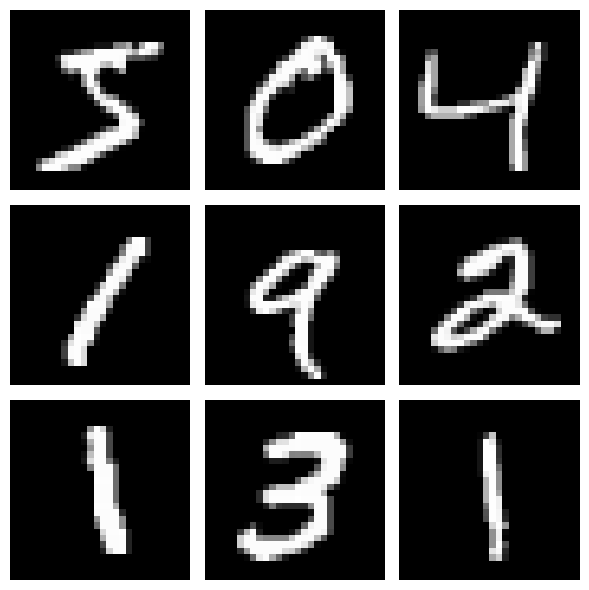

In [1]:
# Load and prepare the MNIST dataset for DCGAN

import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
(X_train, y_train), (_, _) = tf.keras.datasets.mnist.load_data(
    path='mnist.npz'
)

# Display dataset shape
print("Training Images Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)

# Normalize images from [0,255] to [-1,1]

X_train = (X_train.astype('float32') - 127.5) / 127.5

# Reshape images to include channel dimension
# Original shape: (60000, 28, 28)
# New shape: (60000, 28, 28, 1)
X_train = np.expand_dims(X_train, axis=-1)

print("Reshaped Training Images Shape:", X_train.shape)

# Create TensorFlow dataset
BUFFER_SIZE = 60000
BATCH_SIZE = 256

train_dataset = tf.data.Dataset.from_tensor_slices(X_train) \
    .shuffle(BUFFER_SIZE) \
    .batch(BATCH_SIZE)

# Display sample images
plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    # Convert back to [0,1] for display
    img = (X_train[i] + 1) / 2.0

    plt.imshow(img.squeeze(), cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

2. Create the Generator.

In [2]:
# Create the Generator for DCGAN

from tensorflow.keras import layers
import tensorflow as tf

def build_generator():
    model = tf.keras.Sequential(name="Generator")

    # Input: random noise vector
    model.add(layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Reshape to 7x7x256
    model.add(layers.Reshape((7, 7, 256)))

    # Upsample to 14x14
    model.add(
        layers.Conv2DTranspose(
            128,
            kernel_size=(5, 5),
            strides=(1, 1),
            padding='same',
            use_bias=False
        )
    )
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Upsample to 14x14
    model.add(
        layers.Conv2DTranspose(
            64,
            kernel_size=(5, 5),
            strides=(2, 2),
            padding='same',
            use_bias=False
        )
    )
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Upsample to 28x28x1
    model.add(
        layers.Conv2DTranspose(
            1,
            kernel_size=(5, 5),
            strides=(2, 2),
            padding='same',
            use_bias=False,
            activation='tanh'
        )
    )

    return model


# Build generator model
generator = build_generator()

# Display model summary
generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

3. Create the discriminator.

In [3]:
# Create the Discriminator for DCGAN

from tensorflow.keras import layers
import tensorflow as tf

def build_discriminator():
    model = tf.keras.Sequential(name="Discriminator")

    # Input: 28x28x1 image
    model.add(
        layers.Conv2D(
            64,
            kernel_size=(5, 5),
            strides=(2, 2),
            padding='same',
            input_shape=[28, 28, 1]
        )
    )
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # Downsample
    model.add(
        layers.Conv2D(
            128,
            kernel_size=(5, 5),
            strides=(2, 2),
            padding='same'
        )
    )
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # Flatten and classify
    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model


# Build discriminator model
discriminator = build_discriminator()

# Display model summary
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

4. Define the loss and optimizers.

In [4]:
# Define loss functions and optimizers for DCGAN

import tensorflow as tf

# Binary Cross Entropy loss
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)


# Discriminator Loss
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(
        tf.ones_like(real_output), real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output), fake_output
    )

    total_loss = real_loss + fake_loss

    return total_loss


# Generator Loss
def generator_loss(fake_output):
    return cross_entropy(
        tf.ones_like(fake_output), fake_output
    )


# Optimizers
generator_optimizer = tf.keras.optimizers.Adam(1e-4)

discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

print("Loss functions and optimizers are defined.")

Loss functions and optimizers are defined.


5. Define the training loop.

In [5]:
# Define the training loop for DCGAN

import tensorflow as tf
import time

EPOCHS = 50
noise_dim = 100
num_examples_to_generate = 16

# Seed for consistent image generation during training
seed = tf.random.normal([num_examples_to_generate, noise_dim])


@tf.function
def train_step(images):

    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    # Record operations for automatic differentiation
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        # Generate fake images
        generated_images = generator(noise, training=True)

        # Discriminator predictions
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        # Calculate losses
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # Compute gradients
    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    # Apply gradients
    generator_optimizer.apply_gradients(
        zip(gradients_of_generator, generator.trainable_variables)
    )

    discriminator_optimizer.apply_gradients(
        zip(gradients_of_discriminator, discriminator.trainable_variables)
    )


def train(dataset, epochs):

    for epoch in range(epochs):

        start = time.time()

        for image_batch in dataset:
            train_step(image_batch)

        print(
            f"Epoch {epoch + 1}/{epochs} completed in "
            f"{time.time() - start:.2f} seconds"
        )


print("Training loop defined.")

Training loop defined.


6. Train the model.

In [6]:
# Train the DCGAN model

# Start training
train(train_dataset, EPOCHS)

print("Training completed.")

Epoch 1/50 completed in 20.16 seconds
Epoch 2/50 completed in 20.47 seconds
Epoch 3/50 completed in 11.71 seconds
Epoch 4/50 completed in 11.88 seconds
Epoch 5/50 completed in 12.16 seconds
Epoch 6/50 completed in 12.50 seconds
Epoch 7/50 completed in 12.65 seconds
Epoch 8/50 completed in 12.48 seconds
Epoch 9/50 completed in 12.32 seconds
Epoch 10/50 completed in 12.20 seconds
Epoch 11/50 completed in 12.18 seconds
Epoch 12/50 completed in 12.24 seconds
Epoch 13/50 completed in 12.33 seconds
Epoch 14/50 completed in 12.35 seconds
Epoch 15/50 completed in 12.37 seconds
Epoch 16/50 completed in 12.35 seconds
Epoch 17/50 completed in 12.30 seconds
Epoch 18/50 completed in 12.26 seconds
Epoch 19/50 completed in 12.27 seconds
Epoch 20/50 completed in 12.27 seconds
Epoch 21/50 completed in 12.29 seconds
Epoch 22/50 completed in 12.29 seconds
Epoch 23/50 completed in 12.29 seconds
Epoch 24/50 completed in 12.31 seconds
Epoch 25/50 completed in 12.30 seconds
Epoch 26/50 completed in 12.29 sec

7. Create a GIF.

In [20]:
import matplotlib.pyplot as plt
import tensorflow as tf

noise = tf.random.normal([1, 100])

generated_image = generator(noise, training=False)

plt.imshow(
    (generated_image[0, :, :, 0] + 1) / 2.0,
    cmap='gray'
)

plt.axis('off')

plt.savefig('generated_img_0001.png')

plt.close()

print("Image saved!")

Image saved!


In [21]:
# =====================================================
# Create GIF
# =====================================================

import glob
import imageio.v2 as imageio

generated_image_files = sorted(
    glob.glob('generated_img_*.png')
)

print("Images found:", generated_image_files)

with imageio.get_writer(
    'dcgan_training.gif',
    mode='I',
    duration=0.5
) as writer:

    for filename in generated_image_files:

        image = imageio.imread(filename)

        writer.append_data(image)

print("GIF created successfully!")

Images found: ['generated_img_0001.png']
GIF created successfully!


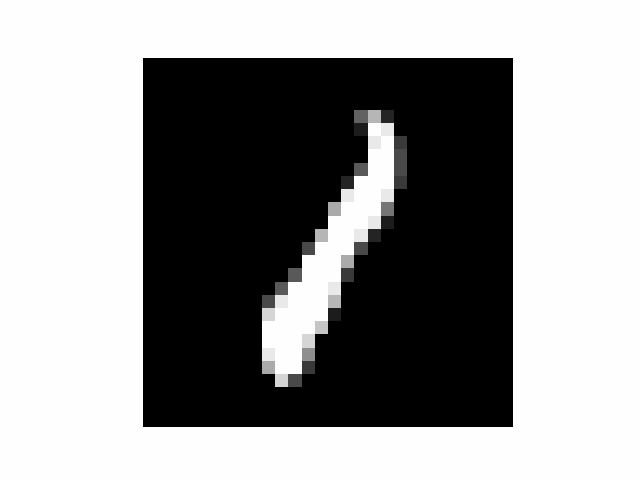

In [22]:
from IPython.display import Image, display

display(Image(filename='dcgan_training.gif'))

In [23]:
# =====================================================
# Generate Multiple Images
# =====================================================

import tensorflow as tf
import matplotlib.pyplot as plt

# Generate 10 images
for i in range(10):

    noise = tf.random.normal([1, 100])

    generated_image = generator(noise, training=False)

    plt.figure(figsize=(2,2))

    plt.imshow(
        (generated_image[0, :, :, 0] + 1) / 2.0,
        cmap='gray'
    )

    plt.axis('off')

    plt.savefig(f'generated_img_{i:04d}.png')

    plt.close()

print("Images generated successfully!")

Images generated successfully!


GIF created successfully!


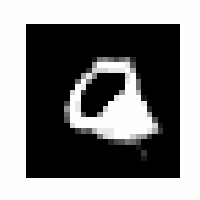

In [24]:
# =====================================================
# Create GIF
# =====================================================

import glob
import imageio.v2 as imageio
from IPython.display import Image, display

generated_image_files = sorted(
    glob.glob('generated_img_*.png')
)

with imageio.get_writer(
    'dcgan_training.gif',
    mode='I',
    duration=0.5
) as writer:

    for filename in generated_image_files:

        image = imageio.imread(filename)

        writer.append_data(image)

print("GIF created successfully!")

display(Image(filename='dcgan_training.gif'))